In [1]:
import pandas as pd
import numpy as np

teams = pd.read_csv("teams.csv")

display(teams.head())


,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0


In [2]:
teams = teams[["team", "country", "year", "athletes", "age", "prev_medals", "medals"]]
display(teams.head())

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0


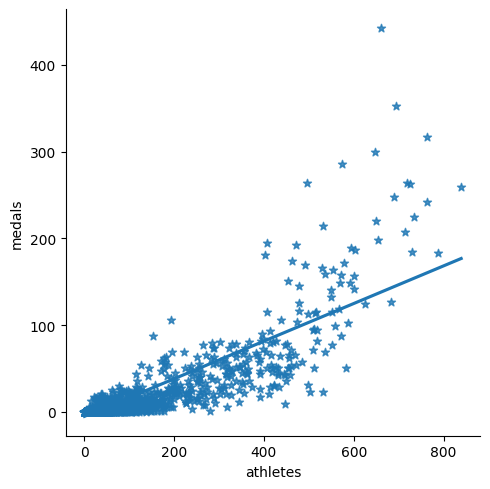

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lmplot(x="athletes", y="medals", data=teams, markers="*", fit_reg=True, ci=None)
plt.show()

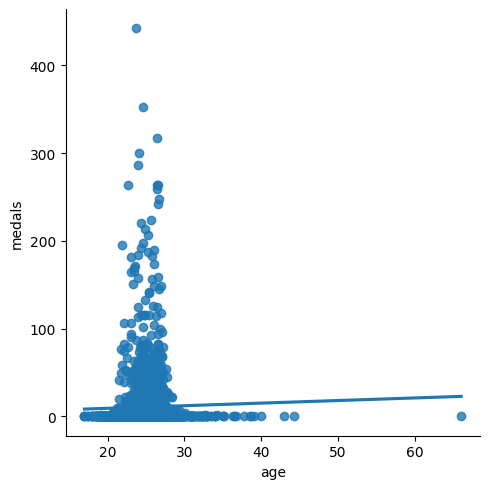

In [4]:
sns.lmplot(x="age", y="medals", data=teams, fit_reg=True, ci=None)

<Axes: ylabel='Frequency'>

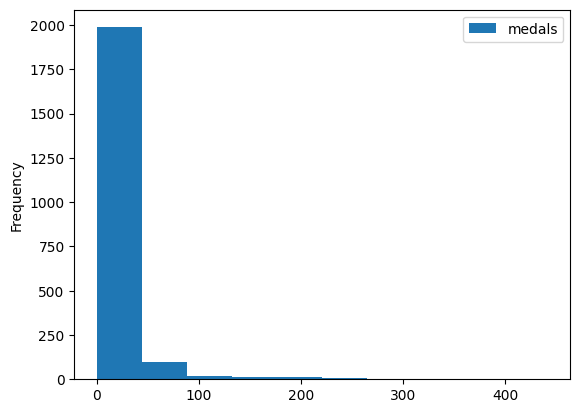

In [5]:
teams.plot.hist(y="medals")

In [6]:
teams.isnull().sum()

team             0
country          0
year             0
athletes         0
age              0
prev_medals    130
medals           0
dtype: int64

In [7]:

teams.isnull().sum()

team             0
country          0
year             0
athletes         0
age              0
prev_medals    130
medals           0
dtype: int64

In [8]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >= 2012].copy()

In [9]:
display(train.shape)
display(test.shape)

(1736, 7)

(408, 7)

In [10]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()

pred = ["athletes", "prev_medals"]
target = "medals"

train = train.fillna(0) 
test = test.fillna(0)

model.fit(train[pred], train[target])

predictions = model.predict(test[pred])

display(predictions)


array([-1.13472078e+00, -1.38329907e+00, -1.51482876e+00, -1.84626647e+00,
        2.31118610e+00,  4.49972044e+00, -1.84626647e+00, -2.01198533e+00,
        5.56656986e-01, -1.89077881e-01, -2.01198533e+00, -1.59768819e+00,
        4.62086031e+01,  3.03993329e+01,  4.49449345e+00,  2.60843465e+00,
       -2.01198533e+00, -1.76340704e+00, -2.01198533e+00, -2.01198533e+00,
        1.46266633e+02,  1.21693971e+02,  7.24856271e+00,  4.69962847e+00,
        7.52610318e+00,  1.04893346e+01,  5.04032029e+00,  3.65141806e+00,
       -1.76340704e+00, -1.76340704e+00, -1.68054762e+00, -1.26625047e+00,
       -1.84626647e+00, -1.51482876e+00,  1.29803444e+01,  1.12258153e+01,
       -1.92912590e+00, -1.84626647e+00, -1.68054762e+00, -1.68054762e+00,
       -2.17770419e+00, -2.17770419e+00, -1.68054762e+00, -1.43196933e+00,
       -2.09484476e+00, -2.09484476e+00,  3.36203967e+01,  2.57881670e+01,
       -1.92912590e+00, -1.34910990e+00, -2.01198533e+00, -4.71845340e-01,
        7.85121268e+01,  

In [11]:
test["predictions"] = predictions
display(test.head())

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,-1.134721
7,AFG,Afghanistan,2016,3,24.7,1.0,0,-1.383299
24,ALB,Albania,2012,10,25.7,0.0,0,-1.514829
25,ALB,Albania,2016,6,23.7,0.0,0,-1.846266
37,ALG,Algeria,2012,39,24.8,2.0,1,2.311186


In [13]:
test["predictions"] = test["predictions"].clip(lower=0)
test["predictions"] = test["predictions"].round()
display(test.head())

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,2.0


In [14]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(test["medals"], test["predictions"])
display(error)

3.343137254901961

In [15]:
teams.describe()["medals"]

count    2144.000000
mean       10.556437
std        33.028143
min         0.000000
25%         0.000000
50%         0.000000
75%         4.000000
max       442.000000
Name: medals, dtype: float64

In [16]:
test[test["team"] == "USA"]

,team,country,year,athletes,age,prev_medals,medals,predictions
2053,USA,United States,2012,689,26.7,317.0,248,280.0
2054,USA,United States,2016,719,26.4,248.0,264,234.0
